---
# <span style="color: #5D3FD3">**Dementia Patient - Health, Prescription,  genetics and lifestyle**  </span>

## <span style="color: #5D3FD3">**Group number 18**  </span>

###  Names of students:
Adi Halili<br>
Shir Yaron<br>
Shira Roth<br>

From:
Link to Kaggle: https://www.kaggle.com/datasets/kaggler2412/dementia-patient-health-and-prescriptions-dataset/data <br>
Kaggle sources: NHS - National Health Service, NIA - National Institute On Aging, PUBMED- National Library of Medicine.

---

<a id='top'></a>

<div style="text-align: center;">
<img src="https://github.com/adihalili/project1/blob/d11331e482fbdcb69ab6b38eed2d108a1343e0f8/dementia_pic1.jpg?raw=true"
width="800"/>
</div>


---
<a id='section0'></a>
## <span style="color: #5D3FD3">Table of Contents:  </span>

1.  Getting to know+clearing the data
2.  First path
3.  Second path
4.  Third path
5.  Summary


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.express as px
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import array as arr
import plotly.graph_objects as go
from IPython.display import display, HTML

---
[back to menu](#section0)

# <span style="color: #BDB5D5">  Getting to know the data: </span>


 <div dir='rtl'>

- הבנת העמודות והנתונים
- הצגת אחוז חולים בריאים
- הצגת הקורולציה 
 <div dir='rtl'>
מכיוון שראינו שאין גורם ישיר ובולט למקרה, התחלנו לחקור לעומק את העמודות ולהצליב מידע בינהן
     
---

In [3]:
url="https://raw.githubusercontent.com/adihalili/project1/main/dementia_patients_health_data.csv"
dmn_df = pd.read_csv(url)
dmn_df.head(10)

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,NaN,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.0,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,NaN,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.0,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.0,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1
5,1,0.114028,94,94.546754,36.678071,66.592329,21.154863,Rivastigmine,1.5,67,...,Former Smoker,Positive,Mild Activity,Yes,1,No,Low-Carb Diet,Poor,Diabetes,1
6,1,0.016194,90,96.423361,37.024630,83.976553,11.350612,Donepezil,10.0,87,...,Never Smoked,Positive,Mild Activity,No,7,No,Mediterranean Diet,Poor,Diabetes,1
7,0,0.161158,98,92.007370,36.050294,69.653564,30.339413,NaN,NaN,66,...,Former Smoker,Negative,Mild Activity,No,9,Yes,Low-Carb Diet,Poor,Hypertension,0
8,0,0.015754,69,99.859490,36.955259,53.725078,36.629687,NaN,NaN,66,...,Former Smoker,Positive,Mild Activity,No,10,Yes,Mediterranean Diet,Poor,NaN,0
9,1,0.097340,64,90.319068,36.396286,58.366698,49.175758,Rivastigmine,3.0,87,...,Former Smoker,Positive,Sedentary,Yes,7,Yes,Balanced Diet,Good,Diabetes,1


In [4]:
dmn_df.shape

(1000, 24)

In [5]:
dmn_df.columns

Index(['Diabetic', 'AlcoholLevel', 'HeartRate', 'BloodOxygenLevel',
       'BodyTemperature', 'Weight', 'MRI_Delay', 'Prescription',
       'Dosage in mg', 'Age', 'Education_Level', 'Dominant_Hand', 'Gender',
       'Family_History', 'Smoking_Status', 'APOE_ε4', 'Physical_Activity',
       'Depression_Status', 'Cognitive_Test_Scores', 'Medication_History',
       'Nutrition_Diet', 'Sleep_Quality', 'Chronic_Health_Conditions',
       'Dementia'],
      dtype='object')

In [6]:
dmn_df.isnull().sum()

Diabetic                       0
AlcoholLevel                   0
HeartRate                      0
BloodOxygenLevel               0
BodyTemperature                0
Weight                         0
MRI_Delay                      0
Prescription                 515
Dosage in mg                 515
Age                            0
Education_Level                0
Dominant_Hand                  0
Gender                         0
Family_History                 0
Smoking_Status                 0
APOE_ε4                        0
Physical_Activity              0
Depression_Status              0
Cognitive_Test_Scores          0
Medication_History             0
Nutrition_Diet                 0
Sleep_Quality                  0
Chronic_Health_Conditions    179
Dementia                       0
dtype: int64

 <div dir='rtl'>
הפכנו ערכים לאינפורמטיבים:

In [7]:
dmn_df['Prescription'].replace(np.nan, "No medication was prescribed", inplace=True)
dmn_df['Dosage in mg'].replace(np.nan, 0, inplace=True) 
dmn_df['Chronic_Health_Conditions'].replace(np.nan, "Not diagnosed with chronic illness", inplace=True)
dmn_df.isnull().sum()

Diabetic                     0
AlcoholLevel                 0
HeartRate                    0
BloodOxygenLevel             0
BodyTemperature              0
Weight                       0
MRI_Delay                    0
Prescription                 0
Dosage in mg                 0
Age                          0
Education_Level              0
Dominant_Hand                0
Gender                       0
Family_History               0
Smoking_Status               0
APOE_ε4                      0
Physical_Activity            0
Depression_Status            0
Cognitive_Test_Scores        0
Medication_History           0
Nutrition_Diet               0
Sleep_Quality                0
Chronic_Health_Conditions    0
Dementia                     0
dtype: int64

 <div dir='rtl'>
ראשית בדקנו את את התפלגות החולים בקרב הנבדקים:
    

In [8]:
dementia_counts = dmn_df['Dementia'].value_counts()
legend_labels = {1: 'Dementia patient', 0: 'No dementia'}
fig = go.Figure(data=[go.Pie(labels=list(legend_labels.values()), marker_colors=['063751', '0E89CB'], values=dementia_counts, textfont_size=15)])
fig.update_layout(width=700, height=500, title='Dementia among the subjects:', title_x=0.25)
fig.show()

 <div dir='rtl'>
החלטנו לעשות קורלציה לכל הדאטה, על מנת לראות קשרים בין הנתונים ולבחור במה להתעמק ולהתמקד:

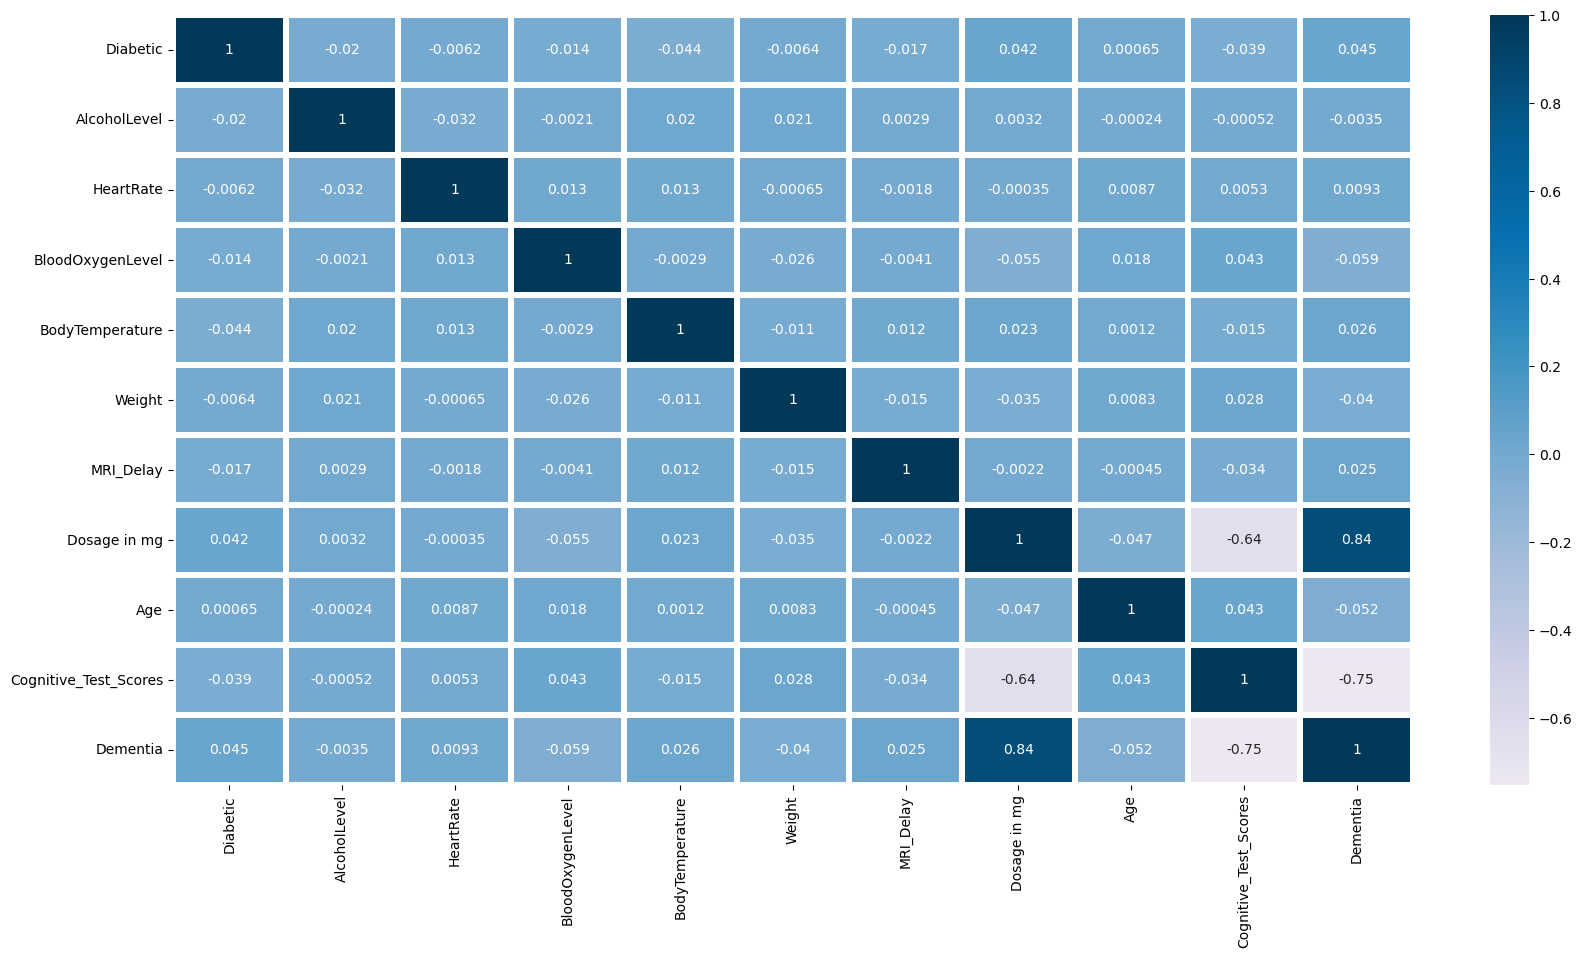

In [9]:
corrs= dmn_df.corr(method= 'kendall', numeric_only= True)
plt.figure(figsize=(20,10))
sns.heatmap(corrs, cmap='PuBu', center= 0, annot = True, linewidths=4)
plt.show()

 <div dir='rtl'>
נשתמש בפונקציית get_dummies כדי לבדוק קורלציה גם בין העמודות שאינן מספריות

In [10]:
dmn_df_dummies = pd.get_dummies(dmn_df)
dmn_df_dummies

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Dosage in mg,Age,Cognitive_Test_Scores,...,Medication_History_Yes,Nutrition_Diet_Balanced Diet,Nutrition_Diet_Low-Carb Diet,Nutrition_Diet_Mediterranean Diet,Sleep_Quality_Good,Sleep_Quality_Poor,Chronic_Health_Conditions_Diabetes,Chronic_Health_Conditions_Heart Disease,Chronic_Health_Conditions_Hypertension,Chronic_Health_Conditions_Not diagnosed with chronic illness
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,0.0,60,10,...,False,False,True,False,False,True,True,False,False,False
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,12.0,61,1,...,True,False,True,False,False,True,False,True,False,False
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,0.0,69,8,...,False,False,False,True,False,True,False,True,False,False
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,23.0,78,5,...,True,True,False,False,False,True,False,False,True,False
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,20.0,77,0,...,True,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,0.081825,87,93.851963,36.495134,50.380106,42.318663,10.0,88,5,...,False,True,False,False,False,True,True,False,False,False
996,1,0.145249,97,94.522391,36.270804,94.006484,52.812568,0.0,80,9,...,True,False,True,False,False,True,True,False,False,False
997,1,0.073692,65,98.578388,37.065703,80.088613,13.640229,0.0,67,8,...,True,True,False,False,True,False,True,False,False,False
998,0,0.037347,71,91.298580,37.037202,95.322210,17.445715,20.0,62,2,...,False,False,True,False,True,False,False,False,False,True


In [11]:
dmn_with_corr=dmn_df_dummies.corr()
dmn_with_corr

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Dosage in mg,Age,Cognitive_Test_Scores,...,Medication_History_Yes,Nutrition_Diet_Balanced Diet,Nutrition_Diet_Low-Carb Diet,Nutrition_Diet_Mediterranean Diet,Sleep_Quality_Good,Sleep_Quality_Poor,Chronic_Health_Conditions_Diabetes,Chronic_Health_Conditions_Heart Disease,Chronic_Health_Conditions_Hypertension,Chronic_Health_Conditions_Not diagnosed with chronic illness
Diabetic,1.000000,-0.025616,-0.007188,-0.016575,-0.053851,-0.007501,-0.020378,0.049210,0.000923,-0.050019,...,-0.006733,-0.009839,0.003021,0.006793,0.055916,-0.055916,1.000000,-0.439574,-0.436213,-0.479236
AlcoholLevel,-0.025616,1.000000,-0.046341,-0.005562,0.030854,0.034553,0.004160,0.008300,-0.003081,-0.018716,...,-0.058951,-0.013902,0.032151,-0.018119,-0.033801,0.033801,-0.025616,-0.055492,0.002164,0.083755
HeartRate,-0.007188,-0.046341,1.000000,0.022283,0.015585,-0.001730,0.000169,-0.020054,0.011665,0.005493,...,0.027799,-0.001782,-0.083193,0.084472,-0.003392,0.003392,-0.007188,-0.020177,0.036131,-0.005509
BloodOxygenLevel,-0.016575,-0.005562,0.022283,1.000000,-0.007265,-0.041081,-0.005760,-0.062321,0.029565,0.070218,...,0.015129,-0.000840,-0.014534,0.015284,-0.017862,0.017862,-0.016575,-0.013011,0.013205,0.021495
BodyTemperature,-0.053851,0.030854,0.015585,-0.007265,1.000000,-0.017750,0.015953,0.045258,0.001586,-0.009791,...,0.022006,0.015300,0.023253,-0.038347,-0.011410,0.011410,-0.053851,0.030771,-0.007905,0.048587
Weight,-0.007501,0.034553,-0.001730,-0.041081,-0.017750,1.000000,-0.022890,-0.029248,0.011739,0.035821,...,-0.057993,-0.020632,-0.000085,0.020625,-0.005504,0.005504,-0.007501,-0.007676,0.031411,-0.012469
MRI_Delay,-0.020378,0.004160,0.000169,-0.005760,0.015953,-0.022890,1.000000,-0.035924,-0.002093,-0.052227,...,0.038864,0.008633,-0.013200,0.004527,-0.002877,0.002877,-0.020378,0.074871,-0.022546,-0.022941
Dosage in mg,0.049210,0.008300,-0.020054,-0.062321,0.045258,-0.029248,-0.035924,1.000000,-0.050452,-0.619073,...,-0.024600,-0.021741,0.021725,0.000048,-0.015638,0.015638,0.049210,-0.048884,-0.010629,-0.008032
Age,0.000923,-0.003081,0.011665,0.029565,0.001586,0.011739,-0.002093,-0.050452,1.000000,0.062640,...,-0.050559,-0.071585,-0.005764,0.076998,-0.003336,0.003336,0.000923,-0.008128,-0.042758,0.046621
Cognitive_Test_Scores,-0.050019,-0.018716,0.005493,0.070218,-0.009791,0.035821,-0.052227,-0.619073,0.062640,1.000000,...,0.013304,0.037301,-0.016316,-0.020917,0.004113,-0.004113,-0.050019,0.046618,0.015205,0.006928


 <div dir='rtl'>
מכל העמודות של הקורלציה מעניין לראות את העמודה של דמנציה - לאילו עמודות יש קורולציה עם הדמנציה ויתכן וגרמו למחלה או השפעה על החולים/הבריאים

In [12]:
dmn_with_corr[["Dementia"]]

,Dementia
Diabetic,0.044815
AlcoholLevel,-0.003720
HeartRate,0.012276
BloodOxygenLevel,-0.071454
BodyTemperature,0.033928
Weight,-0.049563
MRI_Delay,0.031251
Dosage in mg,0.713842
Age,-0.062154
Cognitive_Test_Scores,-0.843247


 <div dir='rtl'>
על מנת להצליח לראות את הקורולציות בבהירות ולהצליח לבחור תחומים בהם נתמקד, נעזרנו בתרשים המציג חזותית את הקורולציות החריגות לשני הכוונים (קורולציה שלילית או חיובית)

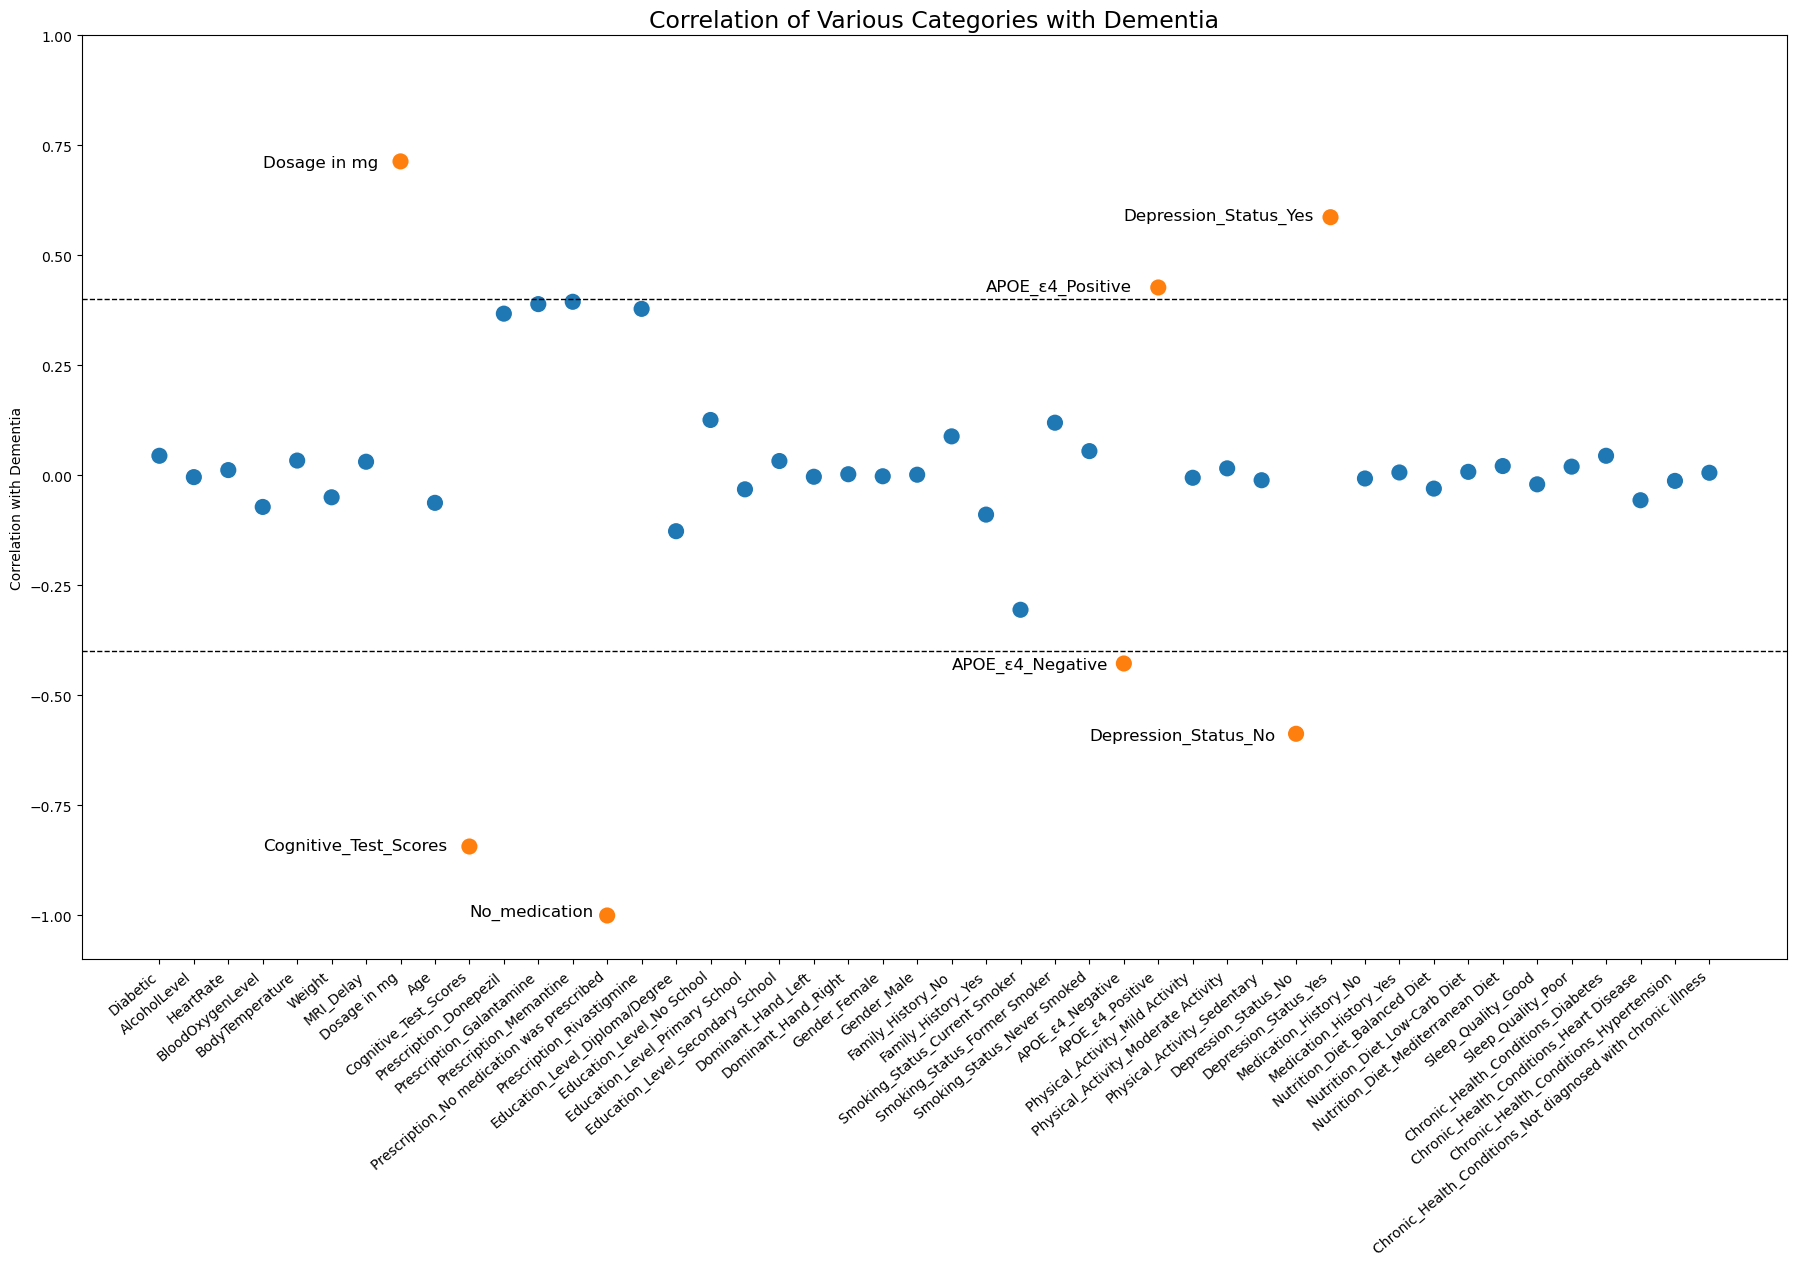

In [13]:
plt.figure(figsize=(22, 12))
dementia_correlations = dmn_with_corr['Dementia'].drop('Dementia')

plot_df = pd.DataFrame({'Category': dementia_correlations.index,'Correlation': dementia_correlations.values})

colors = ['r' if (value >= 0.4 or value <= -0.4) else 'b' for value in dementia_correlations.values]

ax= sns.scatterplot(data=plot_df, x='Category', y='Correlation', hue=colors, s=160, legend=False)
plt.ylabel('Correlation with Dementia')
plt.title('Correlation of Various Categories with Dementia', {'fontsize':17})
plt.axhline(y=-0.4, color='black', linestyle='--', linewidth=1)
plt.axhline(y=0.4, color='black', linestyle='--', linewidth=1)
plt.xlabel(' ') 

plt.ylim(-1.1, 1)
plt.xticks(rotation=40, ha='right')  
font = dict(size=12, color='black')
ax.text(3, 0.7, "Dosage in mg",  **font)
ax.text(3, -0.85, "Cognitive_Test_Scores",  **font)
ax.text(9, -1, "No_medication",  **font)
ax.text(23, -0.44, "APOE_ε4_Negative",  **font)
ax.text(24, 0.42, "APOE_ε4_Positive",  **font)
ax.text(28, 0.58, "Depression_Status_Yes",  **font)
ax.text(27, -0.6, "Depression_Status_No",  **font)

plt.show()

 <div dir='rtl'>
חילקנו את הדאטה לכמה קבוצות שבהן נשתמש בהמשך, (קבוצות נוספות שחילקנו לא הפיקו מסקנה ולכן אינן מוצגות בקובץ).

In [14]:
only_sick= dmn_df[dmn_df['Dementia']==1]
not_sick= dmn_df[dmn_df['Dementia']==0]
with_apoe = dmn_df[dmn_df['APOE_ε4'] == "Positive"]
without_apoe = dmn_df[dmn_df['APOE_ε4'] == "Negative"]


---
[back to menu](#section0)

# <span style="color: #BDB5D5">  First path - Genetics & Education :</span>

 <div dir='rtl'>

- כמה נבדקים הם נשאים של הגן
- כמה חולים נשאים של הגן
- ניסיון להצליב עם נתונים נוספים וחיפוש קשרים בינהם.
- הסקת מסקנה בעזרת הצלבת הגן עם רמות ההשכלה
---

<a id='top'></a>

<div style="text-align: center;">
<img src="https://github.com/adihalili/project1/blob/main/image.png?raw=true"
width="650"/>
</div>


<div dir='rtl'>
מהקורלציה ראינו קשר חזק בין עמודה שנקראת "APOE_E4" לדמנציה. <br>
חיפשנו באינטרנט ולמדנו שזהו  גן שקשור למחלה ומגדיל את הסיכויים לחלות בה.<br>
נבדוק אם ניתן לראות זאת בנתונים שלנו:

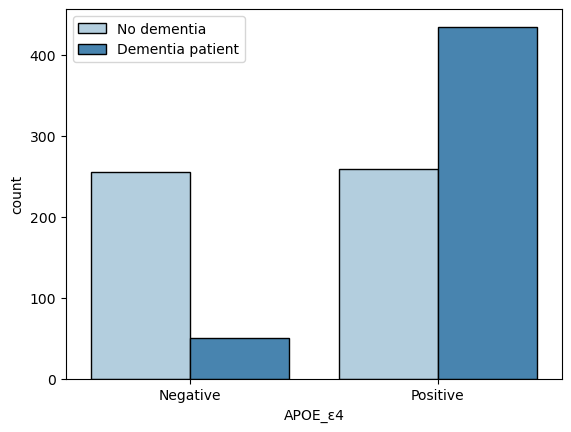

In [15]:
sns.countplot(x='APOE_ε4', hue='Dementia', data=dmn_df,palette='Blues', edgecolor='black')
plt.legend(labels=['No dementia','Dementia patient'])
plt.show()

<div dir='rtl'>  
על מנת לקבל סדרי גודל, נציג את הגרף גם באחוזים:

In [16]:
count_with_apoe=dmn_df[dmn_df['APOE_ε4'] == "Positive"].shape[0]

with_apoe_from_all = [count_with_apoe, dmn_df.shape[0] - count_with_apoe]
labels2= ['with the gene',"without the gene"]
fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'pie'}]])
fig.add_trace(go.Pie(labels=labels2,values=with_apoe_from_all , marker_colors=['063751', '0E89CB'],textfont_size=15) , row=1, col=1)
fig.update_layout(height=450, width=900,title_text="with and without APOE ε4 Gene among the subject:", title_x=0.45)

  <div dir='rtl'>
נראה שרוב הנבדקים נשאים של הגן, מתוך אלה שנשאים של הגן 62.7% חולים. נוכל לראות שבקרב אלה שלא נושאים את הגן, רק 16.3% חולים
 

In [17]:


with_apoe_count_sick = with_apoe[with_apoe['Dementia'] == 1].shape[0]
without_apoe_count_sick = without_apoe[without_apoe['Dementia'] == 1].shape[0]



labels = ['Dementia', 'No Dementia']
values_with_apoe = [with_apoe_count_sick, with_apoe.shape[0] - with_apoe_count_sick]
values_without_apoe = [without_apoe_count_sick, without_apoe.shape[0] - without_apoe_count_sick]

fig = make_subplots(rows=1, cols=2,subplot_titles=('With APOE ε4 Gene', 'Without APOE ε4 Gene'),specs=[[{'type': 'pie'}, {'type': 'pie'}]],horizontal_spacing=0.2)

fig.add_trace(go.Pie( labels=labels,values=values_with_apoe, marker_colors=['063751', '0E89CB'],textfont_size=15), row=1, col=1)
fig.add_trace(go.Pie( labels=labels, values=values_without_apoe , marker_colors=['063751', '0E89CB'],textfont_size=15) , row=1, col=2)

fig.update_layout(height=430, width=900,title_text="Dementia Status with and without APOE ε4 Gene:", title_x=0.5) 


fig.show()


 <div dir='rtl'>
בחרנו להתמקד בחולים עם הגן, בדקנו ומצאנו שמבין כל הגורמים יש קשר עם רמת ההשכלה ורצינו לבחון כיצד משפיעה רמת השכלה על הסיכוי לחלות:


In [18]:
dmn_df.pivot_table('Dementia', index= 'APOE_ε4', columns= 'Education_Level', aggfunc= 'mean')

Education_Level,Diploma/Degree,No School,Primary School,Secondary School
APOE_ε4,,,,
Negative,0.035088,0.225000,0.200000,0.166667
Positive,0.515789,0.773913,0.590909,0.640909


 <div dir='rtl'>
בקרב הנבדקים החיוביים לגן וללא השכלה אחוז החולים היה גבוה - כ77% מתוך הנבדקים שלא למדו ונושאים את הגן חולים

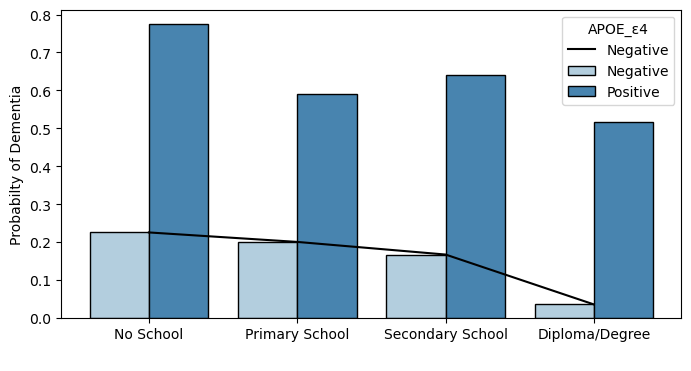

In [19]:
plt.figure(figsize=(8,4))
ax = sns.barplot(data = dmn_df, x='Education_Level', y='Dementia', hue = 'APOE_ε4',errorbar=None, edgecolor='black', order=['No School', 'Primary School', 'Secondary School', 'Diploma/Degree'],palette='Blues')
ax.set_ylabel('Probabilty of Dementia')
ax.set_xlabel(' ') 

dmn_df['Education_Level'] = pd.Categorical(dmn_df['Education_Level'], categories=['No School', 'Primary School', 'Secondary School', 'Diploma/Degree'], ordered=True)
sns.lineplot(dmn_df[dmn_df['APOE_ε4']=='Negative'], x='Education_Level', y='Dementia', hue= 'APOE_ε4', err_style=None, palette={'Negative': 'black'})

plt.legend(title='APOE_ε4', loc=('upper right')) 
plt.show()


<div dir='rtl'>
ניתן לראות שלכל מי שנשא של הגן יש סיכוי גבוה יותר לחלות (בכל רמות ההשכלה). בפרט, בקרב מי שללא השכלה כלל נמצא סיכוי גבוה יותר לחלות.<br> 
נשים לב לפי הקו השחור שהעמודות הבהירות (ללא גן) במגמת ירידה ככל שרמת ההשכלה גדלה. כלומר שמי שאינו נשא של הגן - ככל שילמד יותר כך הסיכוי שלו לחלות שואף ל0.

<!-- <a id="section3"></a>
# <span style="color: #BDB5D5">  Second path - Cognitive test scores & Education :</span>
<div dir='rtl'> -->

---
[back to menu](#section0)

## <span style="color: #BDB5D5">  Second path - Cognitive test scores & Education :</span>

<div dir='rtl'>
    
- חלוקה לחולים ובריאים
- תוצאות מבחנים שונות בין החולים לבריאים
- בדיקה של ציוני הנבדקים לפי רמות השכלה שונות
- הסקת מסקנה על תוצאות החולים בעלי התואר  

---

<a id='top'></a>

<div style="text-align: center;">
<img src="https://github.com/adihalili/project1/blob/main/image%20(1).png?raw=true"
width="850"/>
</div>


 <div dir='rtl'>
בקורלציה שערכנו מול הדמנציה בלטו תוצאות המבחנים הקוגניטיביים של הנבדקים. חיפשנו את התפלגות הציונים:

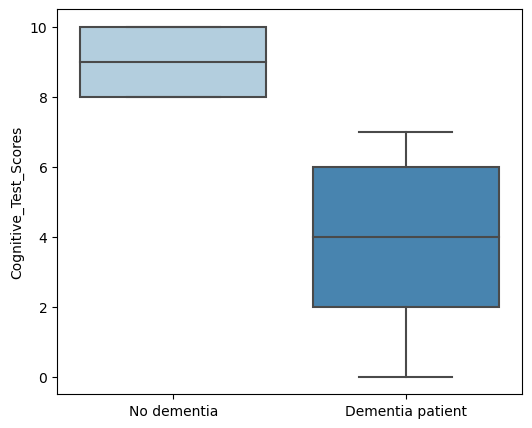

In [20]:
plt.figure(figsize = (6, 5), facecolor = "white")
sns.boxplot(dmn_df, x = 'Dementia', y = 'Cognitive_Test_Scores',palette='Blues')
plt.xticks(ticks=[0, 1], labels=[ 'No dementia','Dementia patient'])
plt.xlabel('')
plt.show()

 <div dir='rtl'>
ניתן לראות התפלגות חד משמעית בין החולים לבריאים במבחן קוגניטיבי.
<br> תוצאות הנבדקים החולים נעו בין 1-7 בלבד, ואילו תוצאות הנבדקים הבריאים נעו בין 8-10 בלבד. (1 - תפקוד נמוך מאוד, 10 - תפקוד גבוה)

 <div dir='rtl'> 
      ראינו קודם שרמת ההשכלה השפיעה על הסיכוי לחלות, רצינו לבדוק באופן כללי מהי התפלגות רמות ההשכלה השונות בקרב הנבדקים ולבדוק אם יהיה קשר לתוצאות המבחן הקוגניטיבי:
    

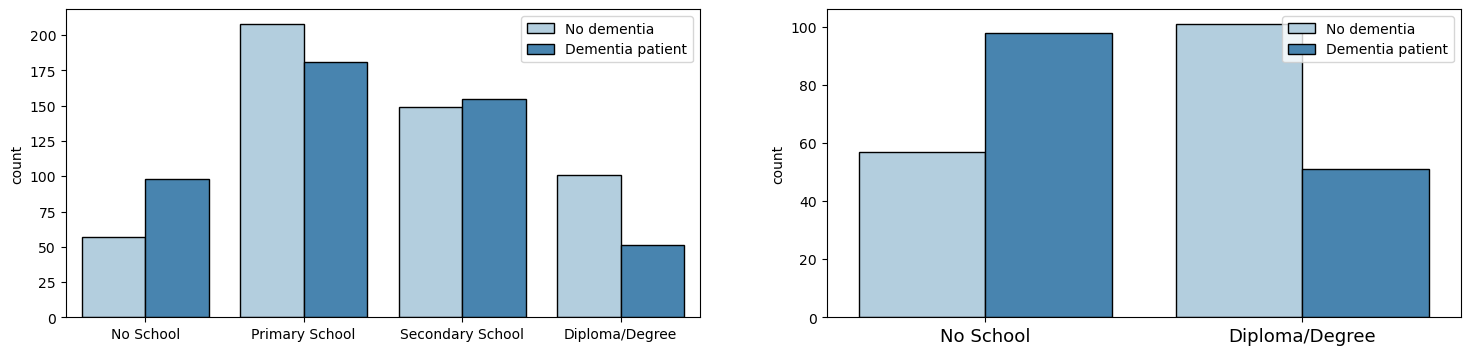

In [21]:
fig, axes = plt.subplots(figsize=(18, 4), ncols=2)
sns.countplot(data = dmn_df, x="Education_Level",hue="Dementia", ax = axes[0],palette='Blues', edgecolor='black')
sns.countplot(data=dmn_df, x='Education_Level', hue='Dementia', order=['No School', 'Diploma/Degree'], ax = axes[1],palette='Blues', edgecolor='black')
axes[0].set_xlabel('') 
axes[1].set_xlabel('')
axes[0].legend(labels=['No dementia', 'Dementia patient'])
axes[1].legend(labels=['No dementia', 'Dementia patient'])
plt.xticks(fontsize=13)
plt.show()

 <div dir='rtl'>
שמנו לב ליחס כמעט הפוך בין חולים שעשו תואר ראשון לבין בריאים שלא למדו בכלל<br>
בחרנו להתמקד בחמישים החולים שעשו תואר ולבדוק אם נוכל לזהות קשר בין רמת ההשכלה הגבוהה שלהם לבין הציון שקיבלו במבחן הקוגניטבי:

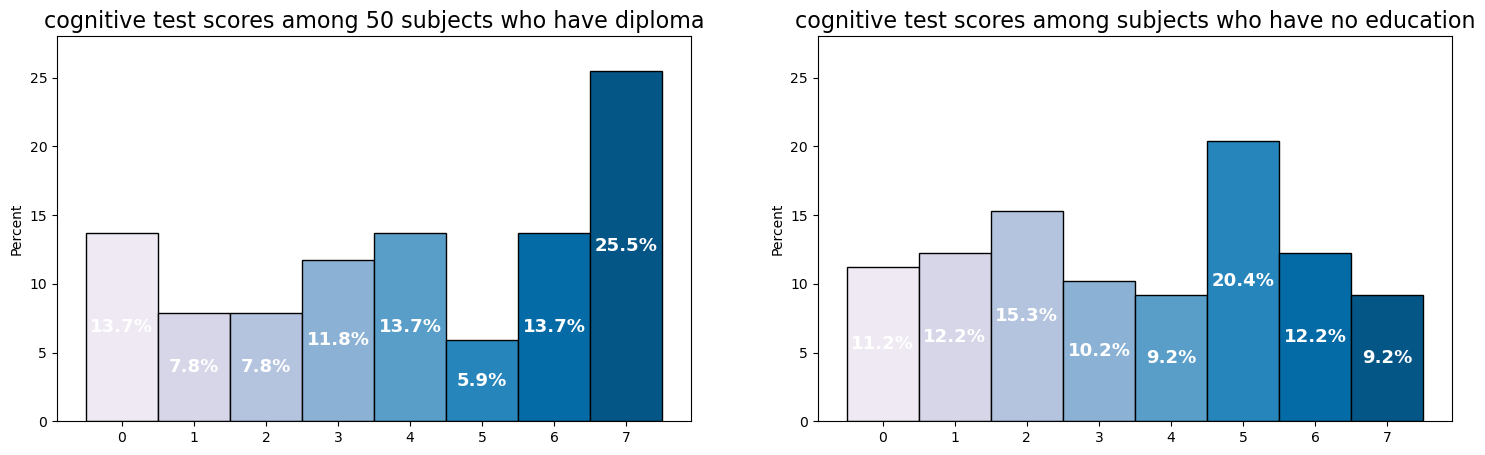

In [22]:
fig, axes = plt.subplots(figsize=(18, 5), ncols=2)

ax1= sns.histplot(only_sick[only_sick['Education_Level']=='Diploma/Degree'], x='Cognitive_Test_Scores',stat='percent', bins=8, discrete=True, ax = axes[0])
ax2= sns.histplot(only_sick[only_sick['Education_Level']=='No School'], x='Cognitive_Test_Scores',stat='percent', bins=8,  discrete=True, ax = axes[1])
ax1.set_ylim(0, 28)
ax2.set_ylim(0, 28)
ax1.set_xlabel('') 
ax2.set_xlabel('') 

for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height / 2),
                 ha='center', va='center', color='white', fontsize=13, fontweight='bold')
    
for i, bar in enumerate(ax1.patches):
    bar.set_facecolor(sns.color_palette("PuBu", 8)[i % 8])
    
for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height / 2), 
                 ha='center', va='center', color='white', fontsize=13, fontweight='bold')

for i, bar in enumerate(ax2.patches):
    bar.set_facecolor(sns.color_palette("PuBu", 8)[i % 8])

ax1.set_title('cognitive test scores among 50 subjects who have diploma', fontsize=16)
ax2.set_title('cognitive test scores among subjects who have no education', fontsize=16)


plt.show()


 <div dir='rtl'>
בגרף נוכל לראות מגמה (אם כי לא אחידה) של רוב ציונים גבוהים יותר לפי רמת ההשכלה.
כלומר, על אף שעדיין חלו, רוב האנשים שעשו תואר ראשון הצליחו להשיג ציונים גבוהים במבחן הקוגניציה. אפשר להסיק מכך על יכולות קוגנטיביות - תפקודיות גבוהות יותר ביחס לחולים האחרים.

---
[back to menu](#section0)

# <span style="color: #BDB5D5"> Third path - Prescription dosage:</span>
 
 <div dir='rtl'>
    
- בדיקת קורלציה בין תרופות לדמנציה   
- השוואת תוצאות המבחנים מול מינון התרופות
- בדיקת השפעת הגילאים על המינון 
- בדיקת השפעת המינון על דיכאון
- המשך בדיקת מינון התרופה המשפיעה על גורמים אחרים
 
---

<a id='top'></a>

<div style="text-align: center;">
<img src="https://github.com/adihalili/project1/blob/main/drug-capsule.jpg?raw=true"
width="800"/>
</div>


 <div dir='rtl'>
בקורלציה הראשונית שערכנו ראינו קשר חזק בין מינון התרופה למחלה. בדקנו וראינו שכל התרופות הן לדמנציה (ולא לטיפול במחלות כרוניות או סכרת), והקורולוציה 1.<br> כלומר, רק מי שחולה נוטל תרופה וכל החולים נוטלים תרופות.

In [23]:
dmn_df.loc[(dmn_df["Prescription"] !='No medication was prescribed'), "Take_Medication"]= 1
dmn_df.loc[(dmn_df["Prescription"] =='No medication was prescribed'), "Take_Medication"]= 0

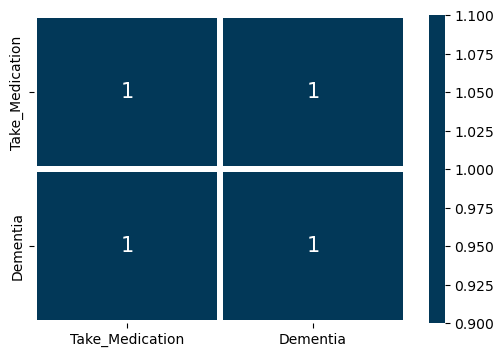

In [33]:
plt.figure(figsize=(6,4))
sns.heatmap( dmn_df[['Take_Medication','Dementia']].corr(), cmap= 'PuBu',center= 0,linewidths=3,annot_kws={"size": 15}, annot = True)
plt.show()

 <div dir='rtl'>
תהינו אם ישנה תרופה אפקטיבית יותר מהאחרות. לשם כך השוונו בין תוצאות מבחן הקוגניציה (שמעיד על רמה קוגנטיבית) בקרב הנבדקים נוטלי ארבעת המרשמים:

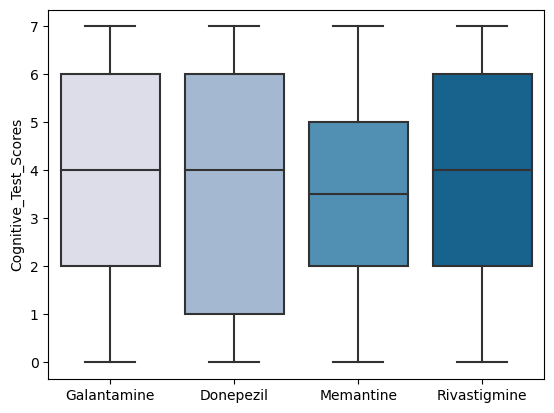

In [25]:
ax= sns.boxplot(x= 'Prescription', y= 'Cognitive_Test_Scores', data= only_sick, palette="PuBu")
ax.set_xlabel('')
plt.show()

 <div dir='rtl'>
מצאנו הבדלים קלים אך לא ניתן להסיק מסקנה חד משמעית על תרופה מסויימת.


 <div dir='rtl'>
בחנו את מינון התרופות בקרב  החולים כשהם מחולקים לפי טווחי גילאים. לשם כך חילקנו את הנבדקים לפי עשורים (טווח הנבדקים הוא בין 60 ל90). הנחנו שעם הגיל יעלה המינון:

In [26]:
dmn_df.loc[dmn_df["Age"] < 70, "Age_level_Group"] = "sixties"
dmn_df.loc[(dmn_df["Age"] >= 70) & (dmn_df["Age"] < 80), "Age_level_Group"] = "seventies"
dmn_df.loc[dmn_df["Age"] >= 80, "Age_level_Group"] = "eighties"

 <div dir='rtl'>
 ביצענו חלוקה נוספת לפי מינוני התרופות, לכל תרופה שלושה מינונים. (לא היה מינון שמוגדר ברמה X בתרופה אחת ובמינון Y בתרופה אחרת ולכן התאפשרה חלוקה זו)

In [27]:
dmn_df.loc[dmn_df["Dosage in mg"].isin([1.5, 5, 4]), "Dosage_level"] = "Low"
dmn_df.loc[dmn_df["Dosage in mg"].isin([10, 8, 3]), "Dosage_level"] = "Medium"
dmn_df.loc[dmn_df["Dosage in mg"].isin([23, 6, 12, 20]), "Dosage_level"] = "High"


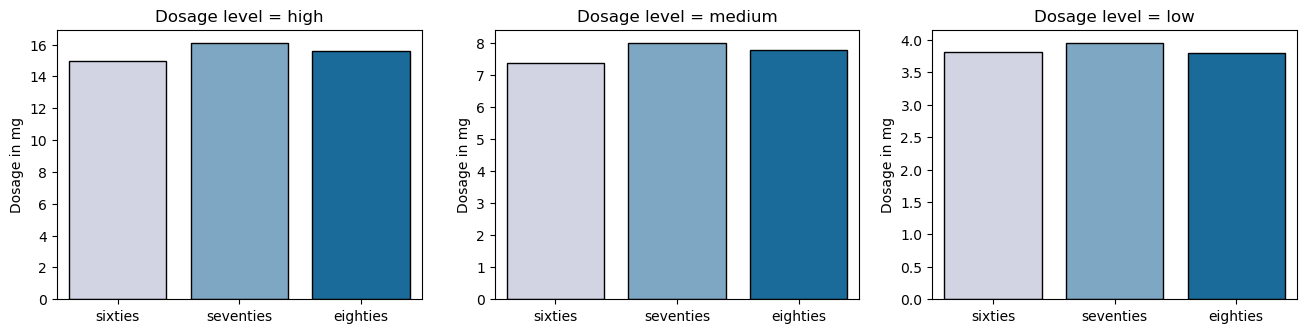

In [28]:
fig, ax = plt.subplots(figsize=(16, 3.5), nrows=1, ncols=3)
sns.barplot(x="Age_level_Group",y="Dosage in mg", data=dmn_df[dmn_df['Dosage_level']=='High'], edgecolor='black', errorbar=None,order=["sixties", "seventies", "eighties"], ax=ax[0],palette="PuBu")
sns.barplot(x="Age_level_Group",y="Dosage in mg", data=dmn_df[dmn_df['Dosage_level']=='Medium'], edgecolor='black', errorbar=None,order=["sixties", "seventies", "eighties"],ax=ax[1],palette="PuBu")
sns.barplot(x="Age_level_Group",y="Dosage in mg", data=dmn_df[dmn_df['Dosage_level']=='Low'], edgecolor='black', errorbar=None,order=["sixties", "seventies", "eighties"], ax=ax[2],palette="PuBu")
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[2].set_xlabel('')

ax[0].set_title('Dosage level = high')
ax[1].set_title('Dosage level = medium')
ax[2].set_title('Dosage level = low')


plt.show()

<div dir='rtl'>
ראינו שלא קיימת עליה במינונים עם עליית הגיל, והמשכנו לבדיקת קשר נוסף - דיכאון ומחלה, כיוון שהיתה קורולציה בינהם.<br>
הנחנו שככל שעולה המינון, יגדל היחס בין חולים המאובחנים עם דיכאון (בשל תופעות לוואי) לבין אלו שאינם ולכן בדקנו לפי המינון הגבוה (בעל ההשפעה החזקה ביותר) את סטטוס הדיכאון בקרב החולים . 

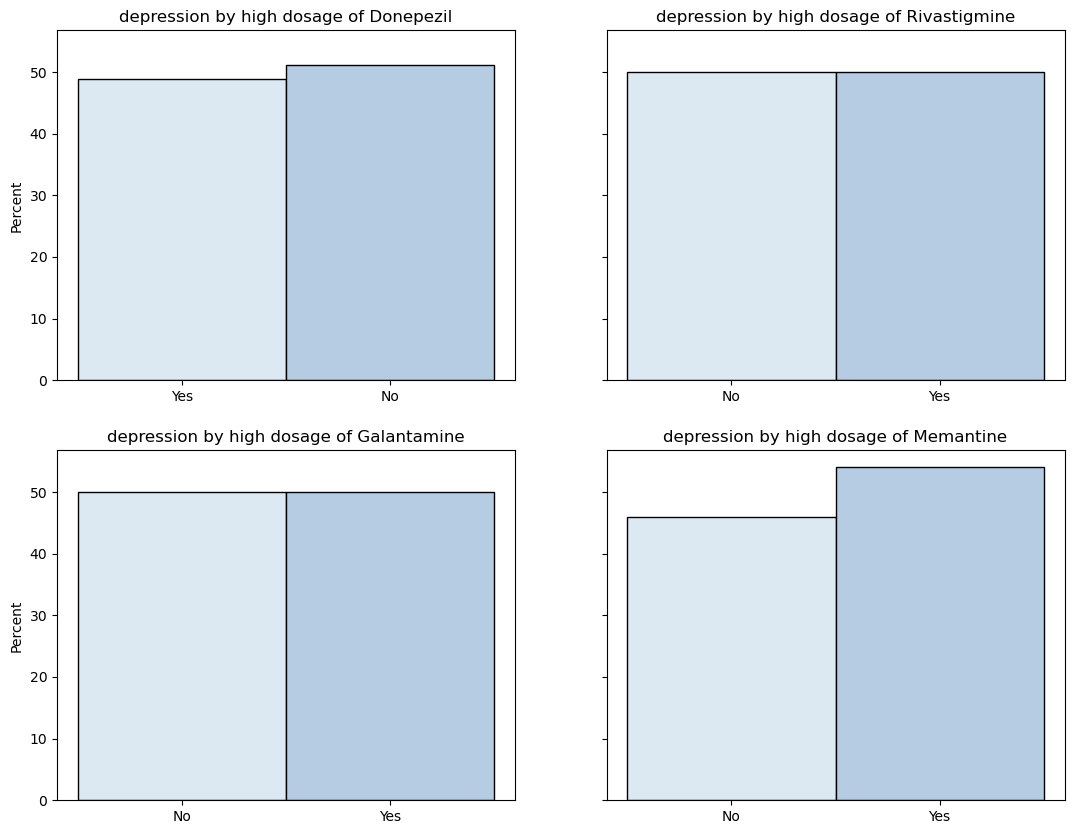

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True)

sns.histplot(data = dmn_df[(dmn_df['Prescription']=='Donepezil')&(dmn_df['Dosage_level']=='High')], x="Depression_Status", ax = axes[0,0], stat= 'percent')
sns.histplot(data = dmn_df[(dmn_df['Prescription']=='Rivastigmine')&(dmn_df['Dosage_level']=='High')], x="Depression_Status", ax = axes[0,1], stat= 'percent')
sns.histplot(data = dmn_df[(dmn_df['Prescription']=='Galantamine')&(dmn_df['Dosage_level']=='High')], x="Depression_Status", ax = axes[1,0], stat= 'percent')
sns.histplot(data = dmn_df[(dmn_df['Prescription']=='Memantine')&(dmn_df['Dosage_level']=='High')], x="Depression_Status", ax = axes[1,1], stat= 'percent')

axes[0,0].set_title('depression by high dosage of Donepezil')
axes[0,1].set_title('depression by high dosage of Rivastigmine')
axes[1,0].set_title('depression by high dosage of Galantamine')
axes[1,1].set_title('depression by high dosage of Memantine')

axes[0,0].set_xlabel('')
axes[0,1].set_xlabel('')
axes[1,0].set_xlabel('')
axes[1,1].set_xlabel('')


for i, bar in enumerate(axes[0,0].patches):
    bar.set_facecolor(sns.color_palette("BuPu")[i % 2])
for i, bar in enumerate(axes[0,1].patches):
    bar.set_facecolor(sns.color_palette("BuPu")[i % 2])
for i, bar in enumerate(axes[1,0].patches):
    bar.set_facecolor(sns.color_palette("BuPu")[i % 2])
for i, bar in enumerate(axes[1,1].patches):
    bar.set_facecolor(sns.color_palette("BuPu")[i % 2])

plt.show()

<div dir='rtl' >
להפתעתנו, לא היה שינוי משמעותי. אבל ראינו שבתרופה אחת "Memantine" יש פער באחוזים של הדיכאון, כלומר אנשים שנוטלים דווקא אותה במינון הגבוה, סובלים יותר מדיכאון. בחרנו להתמקד בה  ולראות אם ישנם עוד הבדלים אצל החולים שנוטלים את התרופה, מתוך הבנה שאם דווקא במינון זה בתרופה זו היתה השפעה על דיכאון, יתכן ונמצא השפעות נוספות.<br>
נבדוק את רמת התפקוד של אותם אנשים, מתוך ההשערה שאם הם סובלים מדיכאון ולוקחים מינון גבוה של התרופה- יתכן ונראה השתקפות ברמת התפקוד. 

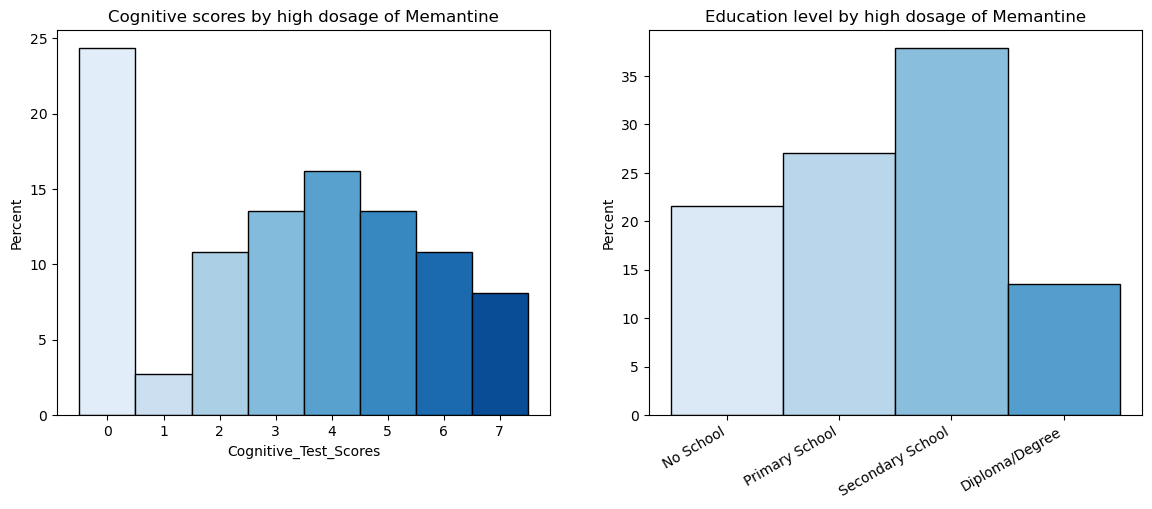

In [30]:
fig, ax = plt.subplots(figsize=(14, 5), nrows=1, ncols=2)

sns.histplot(data = dmn_df[(dmn_df['Prescription']=='Memantine')&(dmn_df['Dosage_level']=='High')], x="Cognitive_Test_Scores",hue='Dosage in mg', legend=False, stat= 'percent', bins=8, discrete=True, ax=ax[0],palette="Blues")
sns.histplot(data = dmn_df[(dmn_df['Prescription']=='Memantine')&(dmn_df['Dosage_level']=='High')], x="Education_Level",hue='Dosage in mg', legend=False, stat= 'percent', bins=4, discrete=True, ax=ax[1],palette="Blues")
plt.xticks(rotation=30, ha='right')
ax[0].set_title('Cognitive scores by high dosage of Memantine')
ax[1].set_title('Education level by high dosage of Memantine')
ax[1].set_xlabel('')
for i, bar in enumerate(ax[0].patches):
    bar.set_facecolor(sns.color_palette("Blues", 8)[i % 8])
for i, bar in enumerate(ax[1].patches):
    bar.set_facecolor(sns.color_palette("Blues")[i % 4])
plt.show()

<div dir='rtl' >
 בתוצאות המבחנים ראינו שרבים מהם הגיעו לציון הנמוך ביותר.
כלומר או בגלל שהם נוטלים את התרופה וסובלים מדיכאון הם מתפקדים פחות טוב, או שלהיפך-התפקוד הנמוך הוא הסיבה לנטילת המינון הגבוה יותר של התרופה, שגורמת לתופעת הלוואי של הדיכאון.
<div dir='rtl' >
בהקשר למסקנה השניה שמצאנו, רצינו לשלול את האפשרות שהנבדקים קיבלו ציונים נמוכים כתוצאה מרמת השכלה נמוכה. תוצאות הגרף אכן הפריכו זאת ואיששו את הגורם הראשוני שמצאנו (מינון התרופה).

<div dir='rtl'>
אחרי שמצאנו שיש תרופה ("Memantine") שבמינון מסויים (20mg) בעלת השפעה שונה משאר המינונים והמרשמים, שיערנו שאולי נוכל למצוא את ההבדל גם בגילאים כפי ששיערנו בהתחלה, בדקנו זאת בשנית הפעם באופן ממוקד 

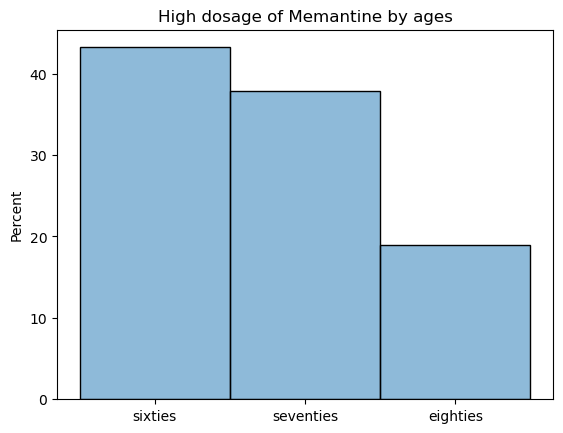

In [31]:
dmn_df['Age_level_Group'] = pd.Categorical(dmn_df['Age_level_Group'], categories=['sixties','seventies','eighties'], ordered=True)
ax= sns.histplot(data = dmn_df[(dmn_df['Prescription']=='Memantine')&(dmn_df['Dosage_level']=='High')], x="Age_level_Group",hue="Dosage_level", stat= 'percent', bins=8, discrete=True,legend=False)
ax.set_xlabel('')
ax.set_title('High dosage of Memantine by ages')

plt.show()

<div dir='rtl'>
מצאנו הבדל אך להפתעתנו- דווקא ככל שהגיל מבוגר יותר, ניתנת פחות התרופה במינונה הגבוה. <br> כשקראנו על התרופה באינטרנט גילינו שבניגוד לאחרות היא מוגדרת לטיפול במצב בינוני עד חמור של המחלה.


---
[back to menu](#section0)

# <span style="color: #BDB5D5">Summary </span>

 <div dir='rtl'>
    
---

<a id='top'></a>

<div style="text-align: center;">
<img src="https://github.com/adihalili/project1/blob/ac10c61af82d5a5d7173b5e83d7f1954c37aa0ee/image%20end.png?raw=true" width="800"
width="800"/>
</div>



#### <div dir='rtl'> מהנתונים שקיבלנו לא ניתן להפיק את מה שהאנושות עוד לא הצליחה להשיג. עם זאת ישנן תובנות שאולי יובילו לכווני חקירה נוספים או לעריכת מחקרים ייעודיים שאנו מקוות ויקדמו אותנו ולו עוד צעד למציאת מרפא למחלה זו. 
 
